# Mixamo 姿态关键点可视化与标准格式转换

这个 notebook 默认**放在你给出的数据根目录**下运行，也就是和 `01 visual_view`、`02 visual_view` ... 同级。

它包含四部分：

1. 自动发现并读取 `bone_coordinates_pixels / image / cam` 三种坐标；
2. 将三种坐标都画到渲染图上预览，其中 `image/cam` 采用“投影到 2D 后去掉 z 轴”的统一可视化方式；
3. 将 Mixamo 骨骼转换到常见标准姿态格式（COCO-17 / OpenPose-18），并提供“严格标准”版本，只保留标准定义内的点；
4. 使用 **RTMLib wholebody** 在渲染图上补全 `nose / left_eye / right_eye / left_ear / right_ear`，再做标准格式预览。

> 说明  
> - `pixels` 通常已经是最接近最终渲染分辨率的 2D 点；  
> - `image` / `cam` 的 JSON 结构在不同导出脚本里可能不同，所以 notebook 里写了**更鲁棒的解析逻辑**；  
> - 对 `cam` / `image` 这里采用“**投影/展平到 2D，忽略 z**”进行可视化比较，便于和 `pixels` 对照；  
> - 对缺失的人脸 5 点，RTMLib 推荐使用 wholebody 方案来补。其仓库 README 提供了 `Wholebody` 的基本用法，仓库中也提供了 `coco17`、`openpose18`、`coco133` 等骨架定义文件，可作为后续标准化输出的依据。 citeturn796946search0turn796946search5turn796946search6

In [ ]:
# !pip install -U matplotlib numpy pillow opencv-python ipywidgets tqdm
# !pip install -U rtmlib onnxruntime onnxruntime-gpu

In [ ]:
import json
import math
import os
from pathlib import Path
from collections import OrderedDict, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import ipywidgets as widgets

try:
    import cv2
except Exception:
    cv2 = None

# RTMLib 默认运行配置
RTMLIB_DEVICE = 'cuda'
RTMLIB_BACKEND = 'onnxruntime'

ROOT = Path('./68 model').resolve()
VIEW_DIRS = sorted([p for p in ROOT.iterdir() if p.is_dir() and p.name.endswith('visual_view')])
print(VIEW_DIRS)
print('ROOT =', ROOT)
print('发现视角目录:')
for p in VIEW_DIRS:
    print(' -', p.name)

[PosixPath('/home/tvem/anime/AniPose/68 model/01 visual_view'), PosixPath('/home/tvem/anime/AniPose/68 model/02 visual_view'), PosixPath('/home/tvem/anime/AniPose/68 model/03 visual_view'), PosixPath('/home/tvem/anime/AniPose/68 model/04 visual_view'), PosixPath('/home/tvem/anime/AniPose/68 model/05 visual_view')]
ROOT = /home/tvem/anime/AniPose/68 model
发现视角目录:
 - 01 visual_view
 - 02 visual_view
 - 03 visual_view
 - 04 visual_view
 - 05 visual_view


In [2]:
plt.rcParams['font.sans-serif'] = ['AR PL UKai CN']
plt.rcParams['axes.unicode_minus'] = False

# 目录配置、基本读取

In [3]:

def view_prefix(view_dir: Path) -> str:
    # "01 visual_view" -> "01"
    return view_dir.name.split()[0]


def rendering_dir(view_dir: Path) -> Path:
    prefix = view_prefix(view_dir)
    return view_dir / f"{prefix}_1 Rendering"

def coord_path(view_dir: Path, mode: str) -> Path:
    prefix = view_prefix(view_dir)
    mapping = {
        'pixels': view_dir / f"{prefix}_9 bone_coordinates_pixels.json",
        'image':  view_dir / f"{prefix}_8 bone_coordinates_image.json",
        'cam':    view_dir / f"{prefix}_7 bone_coordinates_cam.json",
    }
    return mapping[mode]

# load bounding box info, for later use in coordinate conversion
def bbox_path(view_dir: Path) -> Path:
    prefix = view_prefix(view_dir)
    return view_dir / f"{prefix}_10 Bounding_Box.json"


def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


# mode: 'pixels' | 'image' | 'cam'
def try_load_coords(view_dir: Path, mode: str):
    path = coord_path(view_dir, mode)
    if not path.exists():
        raise FileNotFoundError(f'404: {path}')
    return load_json(path)


# sorted by name; filter by extension; return list of Paths 
def list_render_images(view_dir: Path):
    rdir = rendering_dir(view_dir)
    if not rdir.exists():
        return []
    exts = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}
    imgs = [p for p in sorted(rdir.iterdir()) if p.suffix.lower() in exts]
    return imgs


# try to find the image for the given frame_id; 
# if not found, return the closest one by sorted order
def frame_image_path(view_dir: Path, frame_id: int):
    imgs = list_render_images(view_dir)
    if not imgs:
        raise FileNotFoundError(f'rendering目录下没有图片: {rendering_dir(view_dir)}')
    candidates = []
    for p in imgs:
        stem = p.stem
        digits = ''.join(ch for ch in stem if ch.isdigit())
        if digits and int(digits) == frame_id:
            candidates.append(p)
    if candidates:
        return candidates[0]
    # 回退：按排序后的第 frame_id-1 张
    idx = max(0, min(len(imgs)-1, frame_id-1))
    return imgs[idx]


# load image as RGB numpy array
def read_image_rgb(path: Path) -> np.ndarray:
    img = Image.open(path).convert('RGB')
    return np.array(img)



print('number of render images for each view:')
for vd in VIEW_DIRS:
    print(vd.name, len(list_render_images(vd)))

number of render images for each view:
01 visual_view 72
02 visual_view 72
03 visual_view 72
04 visual_view 72
05 visual_view 72


# JSON 坐标解析
对三种尺度下的姿态特征json（pixel image cam）进行解析。

In [4]:
def _as_xy(item):
    if isinstance(item, dict):
        if 'x' in item and 'y' in item:
            return float(item['x']), float(item['y']), float(item.get('z', 0.0))
        # 某些结构可能是 {'X':..., 'Y':..., 'Z':...}
        low = {str(k).lower(): v for k, v in item.items()}
        if 'x' in low and 'y' in low:
            return float(low['x']), float(low['y']), float(low.get('z', 0.0))
    elif isinstance(item, (list, tuple)) and len(item) >= 2:
        x = float(item[0]); y = float(item[1]); z = float(item[2]) if len(item) > 2 else 0.0
        return x, y, z
    return None

def parse_frame_points(frame_obj):
    '''
    将单帧 JSON 解析为:
    {
      joint_name: {'x':..., 'y':..., 'z':...},
      ...
    }
    '''
    out = OrderedDict()

    if isinstance(frame_obj, dict):
        # 最常见：{joint_name: {x,y,z}, ...}
        ok = False
        for k, v in frame_obj.items():
            xy = _as_xy(v)
            if xy is not None:
                out[k] = {'x': xy[0], 'y': xy[1], 'z': xy[2]}
                ok = True
        if ok:
            return out

        # 另一类：{'bones': {...}} / {'joints': {...}} / {'data': {...}}
        for key in ['bones', 'joints', 'data', 'points', 'keypoints']:
            if key in frame_obj and isinstance(frame_obj[key], dict):
                return parse_frame_points(frame_obj[key])

        # 再退化：遍历子节点寻找 joint dict
        for k, v in frame_obj.items():
            if isinstance(v, dict):
                nested = parse_frame_points(v)
                if nested:
                    return nested

    elif isinstance(frame_obj, list):
        # 可能是 [{'name':..., 'x':..., 'y':..., 'z':...}, ...]
        for item in frame_obj:
            if isinstance(item, dict):
                name = item.get('name') or item.get('joint') or item.get('bone')
                xy = _as_xy(item)
                if name is not None and xy is not None:
                    out[str(name)] = {'x': xy[0], 'y': xy[1], 'z': xy[2]}
        if out:
            return out

    return out

def load_points_for_frame(view_dir: Path, mode: str, frame_id: int):
    data = try_load_coords(view_dir, mode)
    key = str(frame_id)
    if key not in data:
        # 某些导出可能是 0-based 或带前导零
        candidates = [key, f"{frame_id:04d}", str(frame_id-1), f"{frame_id-1:04d}"]
        for c in candidates:
            if c in data:
                key = c
                break
        else:
            raise KeyError(f'{mode} 中找不到 frame={frame_id}，可用键示例: {list(data.keys())[:5]}')
    pts = parse_frame_points(data[key])
    if not pts:
        raise ValueError(f'无法解析 {mode} 的 frame={frame_id} 关键点结构')
    return pts

def points_to_array(points_dict):
    names = list(points_dict.keys())
    arr = np.array([[points_dict[n]['x'], points_dict[n]['y'], points_dict[n].get('z', 0.0)] for n in names], dtype=float)
    return names, arr

# 抽样检查
sample_view = VIEW_DIRS[0]
for mode in ['pixels', 'image', 'cam']:
    pts = load_points_for_frame(sample_view, mode, 1)
    print(mode, '关键点数 =', len(pts), '示例 =', list(pts.keys())[:8])

pixels 关键点数 = 65 示例 = ['mixamorig:Hips', 'mixamorig:Spine', 'mixamorig:Spine1', 'mixamorig:Spine2', 'mixamorig:Neck', 'mixamorig:Head', 'mixamorig:HeadTop_End', 'mixamorig:LeftShoulder']
image 关键点数 = 65 示例 = ['mixamorig:Hips', 'mixamorig:Spine', 'mixamorig:Spine1', 'mixamorig:Spine2', 'mixamorig:Neck', 'mixamorig:Head', 'mixamorig:HeadTop_End', 'mixamorig:LeftShoulder']
cam 关键点数 = 65 示例 = ['mixamorig:Hips', 'mixamorig:Spine', 'mixamorig:Spine1', 'mixamorig:Spine2', 'mixamorig:Neck', 'mixamorig:Head', 'mixamorig:HeadTop_End', 'mixamorig:LeftShoulder']


##  骨架连线（Mixamo）

In [5]:
MIXAMO_EDGES = [
    ('mixamorig:Hips', 'mixamorig:Spine'),
    ('mixamorig:Spine', 'mixamorig:Spine1'),
    ('mixamorig:Spine1', 'mixamorig:Spine2'),
    ('mixamorig:Spine2', 'mixamorig:Neck'),
    ('mixamorig:Neck', 'mixamorig:Head'),
    ('mixamorig:Head', 'mixamorig:HeadTop_End'),

    ('mixamorig:Neck', 'mixamorig:LeftShoulder'),
    ('mixamorig:LeftShoulder', 'mixamorig:LeftArm'),
    ('mixamorig:LeftArm', 'mixamorig:LeftForeArm'),
    ('mixamorig:LeftForeArm', 'mixamorig:LeftHand'),

    ('mixamorig:Neck', 'mixamorig:RightShoulder'),
    ('mixamorig:RightShoulder', 'mixamorig:RightArm'),
    ('mixamorig:RightArm', 'mixamorig:RightForeArm'),
    ('mixamorig:RightForeArm', 'mixamorig:RightHand'),

    ('mixamorig:Hips', 'mixamorig:LeftUpLeg'),
    ('mixamorig:LeftUpLeg', 'mixamorig:LeftLeg'),
    ('mixamorig:LeftLeg', 'mixamorig:LeftFoot'),
    ('mixamorig:LeftFoot', 'mixamorig:LeftToeBase'),
    ('mixamorig:LeftToeBase', 'mixamorig:LeftToe_End'),

    ('mixamorig:Hips', 'mixamorig:RightUpLeg'),
    ('mixamorig:RightUpLeg', 'mixamorig:RightLeg'),
    ('mixamorig:RightLeg', 'mixamorig:RightFoot'),
    ('mixamorig:RightFoot', 'mixamorig:RightToeBase'),
    ('mixamorig:RightToeBase', 'mixamorig:RightToe_End'),
]

LEFT_HAND_FINGERS = [
    ['mixamorig:LeftHand', 'mixamorig:LeftHandThumb1', 'mixamorig:LeftHandThumb2', 'mixamorig:LeftHandThumb3', 'mixamorig:LeftHandThumb4'],
    ['mixamorig:LeftHand', 'mixamorig:LeftHandIndex1', 'mixamorig:LeftHandIndex2', 'mixamorig:LeftHandIndex3', 'mixamorig:LeftHandIndex4'],
    ['mixamorig:LeftHand', 'mixamorig:LeftHandMiddle1', 'mixamorig:LeftHandMiddle2', 'mixamorig:LeftHandMiddle3', 'mixamorig:LeftHandMiddle4'],
    ['mixamorig:LeftHand', 'mixamorig:LeftHandRing1', 'mixamorig:LeftHandRing2', 'mixamorig:LeftHandRing3', 'mixamorig:LeftHandRing4'],
    ['mixamorig:LeftHand', 'mixamorig:LeftHandPinky1', 'mixamorig:LeftHandPinky2', 'mixamorig:LeftHandPinky3', 'mixamorig:LeftHandPinky4'],
]
RIGHT_HAND_FINGERS = [
    ['mixamorig:RightHand', 'mixamorig:RightHandThumb1', 'mixamorig:RightHandThumb2', 'mixamorig:RightHandThumb3', 'mixamorig:RightHandThumb4'],
    ['mixamorig:RightHand', 'mixamorig:RightHandIndex1', 'mixamorig:RightHandIndex2', 'mixamorig:RightHandIndex3', 'mixamorig:RightHandIndex4'],
    ['mixamorig:RightHand', 'mixamorig:RightHandMiddle1', 'mixamorig:RightHandMiddle2', 'mixamorig:RightHandMiddle3', 'mixamorig:RightHandMiddle4'],
    ['mixamorig:RightHand', 'mixamorig:RightHandRing1', 'mixamorig:RightHandRing2', 'mixamorig:RightHandRing3', 'mixamorig:RightHandRing4'],
    ['mixamorig:RightHand', 'mixamorig:RightHandPinky1', 'mixamorig:RightHandPinky2', 'mixamorig:RightHandPinky3', 'mixamorig:RightHandPinky4'],
]

for finger in LEFT_HAND_FINGERS + RIGHT_HAND_FINGERS:
    for a, b in zip(finger[:-1], finger[1:]):
        MIXAMO_EDGES.append((a, b))

def draw_points(ax, points, title='', image=None, show_labels=False, edges=None, invert_y=False, point_size=20):
    if image is not None:
        ax.imshow(image)
    xs = [v['x'] for v in points.values()]
    ys = [v['y'] for v in points.values()]
    ax.scatter(xs, ys, s=point_size)
    if edges:
        for a, b in edges:
            if a in points and b in points:
                ax.plot([points[a]['x'], points[b]['x']],
                        [points[a]['y'], points[b]['y']], linewidth=1)
    if show_labels:
        for name, p in points.items():
            ax.text(p['x'], p['y'], name.split(':')[-1], fontsize=7)
    ax.set_title(title)
    if invert_y and image is None:
        ax.invert_yaxis()
    ax.set_aspect('equal', adjustable='box')

## 坐标模式对比预览

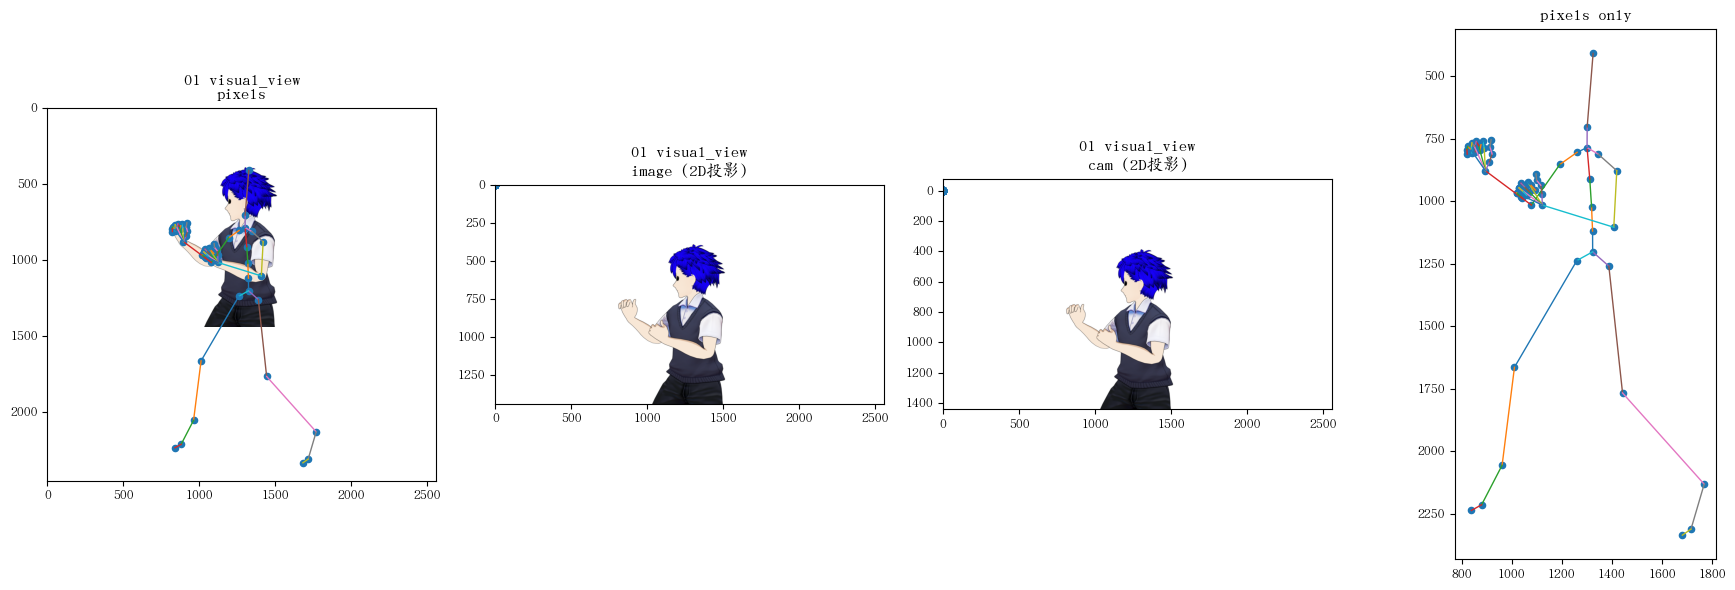

In [6]:
def maybe_project_to_2d(points, strategy='drop_z'):
    '''
    统一转换到 2D 可视化坐标:
    - strategy='drop_z': 直接取 x, y
    - 这里保留 z 只是为了接口一致
    '''
    out = OrderedDict()
    for k, v in points.items():
        out[k] = {'x': float(v['x']), 'y': float(v['y']), 'z': float(v.get('z', 0.0))}
    return out

def compare_coordinate_modes(view_name=None, frame_id=1, show_labels=False, figsize=(18, 6)):
    if view_name is None:
        view_dir = VIEW_DIRS[0]
    else:
        matches = [p for p in VIEW_DIRS if p.name == view_name]
        if not matches:
            raise ValueError(f'找不到视角目录: {view_name}')
        view_dir = matches[0]

    img_path = frame_image_path(view_dir, frame_id)
    img = read_image_rgb(img_path)

    pixels = maybe_project_to_2d(load_points_for_frame(view_dir, 'pixels', frame_id))
    imagep = maybe_project_to_2d(load_points_for_frame(view_dir, 'image', frame_id))
    camp   = maybe_project_to_2d(load_points_for_frame(view_dir, 'cam', frame_id))

    fig, axes = plt.subplots(1, 4, figsize=figsize)
    draw_points(axes[0], pixels, title=f'{view_dir.name}\npixels', image=img, show_labels=show_labels, edges=MIXAMO_EDGES)
    draw_points(axes[1], imagep, title=f'{view_dir.name}\nimage (2D投影)', image=img, show_labels=show_labels, edges=MIXAMO_EDGES)
    draw_points(axes[2], camp,   title=f'{view_dir.name}\ncam (2D投影)', image=img, show_labels=show_labels, edges=MIXAMO_EDGES)
    draw_points(axes[3], pixels, title='pixels only', image=None, show_labels=show_labels, edges=MIXAMO_EDGES, invert_y=True)
    plt.tight_layout()
    plt.show()

compare_coordinate_modes(frame_id=1, show_labels=False)

In [7]:
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt

def maybe_project_to_2d(points, strategy='drop_z'):
    """
    统一转换到 2D 可视化坐标:
    - strategy='drop_z': 直接取 x, y
    """
    out = OrderedDict()
    for k, v in points.items():
        out[k] = {
            'x': float(v['x']),
            'y': float(v['y']),
            'z': float(v.get('z', 0.0)),
        }
    return out


def points_dict_to_xy(points, joint_names=None):
    """
    points -> (names, xy)
    xy: [N, 2]
    """
    if joint_names is None:
        joint_names = list(points.keys())
    names = []
    xy = []
    for n in joint_names:
        if n in points:
            names.append(n)
            xy.append([points[n]['x'], points[n]['y']])
    if len(xy) == 0:
        return [], np.zeros((0, 2), dtype=float)
    return names, np.asarray(xy, dtype=float)


def apply_affine_to_points(points, A, t):
    """
    对 points 应用 2x2 仿射矩阵 A 和平移 t
    dst = src @ A.T + t
    """
    out = OrderedDict()
    for k, v in points.items():
        src = np.array([float(v['x']), float(v['y'])], dtype=float)
        dst = src @ A.T + t
        out[k] = {
            'x': float(dst[0]),
            'y': float(dst[1]),
            'z': float(v.get('z', 0.0)),
        }
    return out


def fit_affine_from_correspondences(src_points, dst_points, min_joints=6):
    """
    用共同关节拟合 2D 仿射:
        dst = src @ A.T + t

    src_points: image/cam
    dst_points: pixels
    """
    common = [k for k in src_points.keys() if k in dst_points]
    if len(common) < min_joints:
        raise ValueError(f'共同点太少，无法拟合仿射变换: {len(common)} < {min_joints}')

    _, src_xy = points_dict_to_xy(src_points, common)
    _, dst_xy = points_dict_to_xy(dst_points, common)

    # 构造最小二乘:
    # [x y 1] @ M = [X Y]
    X = np.concatenate([src_xy, np.ones((len(src_xy), 1), dtype=float)], axis=1)   # [N, 3]
    Y = dst_xy                                                                      # [N, 2]

    M, *_ = np.linalg.lstsq(X, Y, rcond=None)  # M: [3, 2]

    # dst = src @ A.T + t
    A = M[:2, :].T   # [2, 2]
    t = M[2, :]      # [2]
    return A, t, common


def normalize_points_to_image(points, img_shape, keep_aspect=True, pad=0.05):
    """
    兜底方案：
    如果拟合失败，就把点云 bbox 归一化映射到图像尺寸内。
    注意：这只是为了“能看”，不保证严格几何对应。
    """
    h, w = img_shape[:2]
    xs = np.array([v['x'] for v in points.values()], dtype=float)
    ys = np.array([v['y'] for v in points.values()], dtype=float)

    min_x, max_x = xs.min(), xs.max()
    min_y, max_y = ys.min(), ys.max()

    src_w = max(max_x - min_x, 1e-6)
    src_h = max(max_y - min_y, 1e-6)

    tgt_w = w * (1 - 2 * pad)
    tgt_h = h * (1 - 2 * pad)

    if keep_aspect:
        s = min(tgt_w / src_w, tgt_h / src_h)
        sx = sy = s
    else:
        sx = tgt_w / src_w
        sy = tgt_h / src_h

    tx = w * pad - min_x * sx + (tgt_w - src_w * sx) / 2
    ty = h * pad - min_y * sy + (tgt_h - src_h * sy) / 2

    A = np.array([[sx, 0.0], [0.0, sy]], dtype=float)
    t = np.array([tx, ty], dtype=float)
    return apply_affine_to_points(points, A, t), A, t


def align_points_to_pixels(src_points, pixel_points, img_shape=None, min_joints=6):
    """
    优先：用 src -> pixels 的仿射拟合
    失败时：fallback 到 bbox 归一化
    """
    try:
        A, t, common = fit_affine_from_correspondences(src_points, pixel_points, min_joints=min_joints)
        aligned = apply_affine_to_points(src_points, A, t)
        return aligned, {
            'method': 'affine_to_pixels',
            'num_common_joints': len(common),
            'A': A,
            't': t,
        }
    except Exception as e:
        if img_shape is None:
            raise
        aligned, A, t = normalize_points_to_image(src_points, img_shape)
        return aligned, {
            'method': 'normalize_to_image_fallback',
            'reason': str(e),
            'A': A,
            't': t,
        }


def compare_coordinate_modes(view_name=None, frame_id=1, show_labels=False, figsize=(20, 6), num_subplots=5):
    if view_name is None:
        view_dir = VIEW_DIRS[0]
    else:
        matches = [p for p in VIEW_DIRS if p.name == view_name]
        if not matches:
            raise ValueError(f'找不到视角目录: {view_name}')
        view_dir = matches[0]

    img_path = frame_image_path(view_dir, frame_id)
    img = read_image_rgb(img_path)

    pixels_raw = load_points_for_frame(view_dir, 'pixels', frame_id)
    image_raw  = load_points_for_frame(view_dir, 'image', frame_id)
    cam_raw    = load_points_for_frame(view_dir, 'cam', frame_id)

    pixels = maybe_project_to_2d(pixels_raw)
    imagep = maybe_project_to_2d(image_raw)
    camp   = maybe_project_to_2d(cam_raw)

    # 关键：把 image / cam 对齐到 pixels 坐标系
    imagep_aligned, image_meta = align_points_to_pixels(imagep, pixels, img_shape=img.shape)
    camp_aligned, cam_meta     = align_points_to_pixels(camp, pixels, img_shape=img.shape)

    fig, axes = plt.subplots(1, num_subplots, figsize=figsize)

    draw_points(
        axes[0], pixels,
        title=f'{view_dir.name}\npixels (原始像素坐标)',
        image=img,
        show_labels=show_labels,
        edges=MIXAMO_EDGES
    )

    draw_points(
        axes[1], imagep_aligned,
        title=f'{view_dir.name}\nimage -> pixels\n{image_meta["method"]}',
        image=img,
        show_labels=show_labels,
        edges=MIXAMO_EDGES
    )

    draw_points(
        axes[2], camp_aligned,
        title=f'{view_dir.name}\ncam -> pixels\n{cam_meta["method"]}',
        image=img,
        show_labels=show_labels,
        edges=MIXAMO_EDGES
    )

    # 第4张图：三种模式对比到同一平面
    axes[3].imshow(img)
    draw_points(axes[3], pixels, image=None, title='overlay compare', show_labels=False, edges=MIXAMO_EDGES)
    draw_points(axes[3], imagep_aligned, image=None, title='overlay compare', show_labels=False, edges=None)
    draw_points(axes[3], camp_aligned, image=None, title='overlay compare', show_labels=False, edges=None)
    axes[3].set_title('overlay compare\npixels + image_aligned + cam_aligned')

    
    draw_points(axes[4], pixels, title='pixels only', image=None, show_labels=show_labels, edges=MIXAMO_EDGES, invert_y=True)
    

    plt.tight_layout()
    plt.show()

    print('image 对齐信息:', image_meta)
    print('cam   对齐信息:', cam_meta)


# compare_coordinate_modes(frame_id=1, show_labels=False)

交互式预览：绘制三种 coordinate 模式，并和 pixels 对比


In [8]:
view_dropdown = widgets.Dropdown(options=[p.name for p in VIEW_DIRS], value=VIEW_DIRS[0].name, description='View')
frame_slider = widgets.IntSlider(value=1, min=1, max=72, step=1, description='Frame')
label_check = widgets.Checkbox(value=False, description='显示标签')

ui = widgets.HBox([view_dropdown, frame_slider, label_check])
out = widgets.interactive_output(
    lambda view_name, frame_id, show_labels: compare_coordinate_modes(view_name=view_name, frame_id=frame_id, show_labels=show_labels),
    {'view_name': view_dropdown, 'frame_id': frame_slider, 'show_labels': label_check}
)
display(ui, out)

Output()

# 把特征点映射到通用标准
把特征点映射到下面两种标准
- coco17
- openpose18

In [9]:
# COCO-17
COCO17_ORDER = [
    'nose',
    'left_eye', 'right_eye',
    'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder',
    'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist',
    'left_hip', 'right_hip',
    'left_knee', 'right_knee',
    'left_ankle', 'right_ankle',
]

COCO17_EDGES = [
    ('left_eye', 'right_eye'),
    ('nose', 'left_eye'), ('nose', 'right_eye'),
    ('left_eye', 'left_ear'), ('right_eye', 'right_ear'),
    ('left_shoulder', 'right_shoulder'),
    ('left_shoulder', 'left_elbow'), ('left_elbow', 'left_wrist'),
    ('right_shoulder', 'right_elbow'), ('right_elbow', 'right_wrist'),
    ('left_shoulder', 'left_hip'), ('right_shoulder', 'right_hip'),
    ('left_hip', 'right_hip'),
    ('left_hip', 'left_knee'), ('left_knee', 'left_ankle'),
    ('right_hip', 'right_knee'), ('right_knee', 'right_ankle'),
]

#  OpenPose-18
OPENPOSE18_ORDER = [
    'nose',
    'neck',
    'right_shoulder', 'right_elbow', 'right_wrist',
    'left_shoulder', 'left_elbow', 'left_wrist',
    'mid_hip',
    'right_hip', 'right_knee', 'right_ankle',
    'left_hip', 'left_knee', 'left_ankle',
    'right_eye', 'left_eye',
    'right_ear', 'left_ear',
]

OPENPOSE18_EDGES = [
    ('nose', 'neck'),
    ('neck', 'right_shoulder'), ('right_shoulder', 'right_elbow'), ('right_elbow', 'right_wrist'),
    ('neck', 'left_shoulder'), ('left_shoulder', 'left_elbow'), ('left_elbow', 'left_wrist'),
    ('neck', 'mid_hip'),
    ('mid_hip', 'right_hip'), ('right_hip', 'right_knee'), ('right_knee', 'right_ankle'),
    ('mid_hip', 'left_hip'), ('left_hip', 'left_knee'), ('left_knee', 'left_ankle'),
    ('nose', 'right_eye'), ('right_eye', 'right_ear'),
    ('nose', 'left_eye'), ('left_eye', 'left_ear'),
]

MIXAMO_TO_STD_BASE = {
    'left_shoulder': 'mixamorig:LeftArm',
    'right_shoulder': 'mixamorig:RightArm',
    'left_elbow': 'mixamorig:LeftForeArm',
    'right_elbow': 'mixamorig:RightForeArm',
    'left_wrist': 'mixamorig:LeftHand',
    'right_wrist': 'mixamorig:RightHand',
    'left_hip': 'mixamorig:LeftUpLeg',
    'right_hip': 'mixamorig:RightUpLeg',
    'left_knee': 'mixamorig:LeftLeg',
    'right_knee': 'mixamorig:RightLeg',
    'left_ankle': 'mixamorig:LeftFoot',
    'right_ankle': 'mixamorig:RightFoot',
    'neck': 'mixamorig:Neck',
}

def midpoint(a, b):
    return {
        'x': (a['x'] + b['x']) / 2.0,
        'y': (a['y'] + b['y']) / 2.0,
        'z': (a.get('z', 0.0) + b.get('z', 0.0)) / 2.0,
    }

def convert_mixamo_to_standard(mixamo_points, standard='coco17', extra_face_points=None, strict=True):
    '''
    extra_face_points:
      {
        'nose': {...}, 'left_eye': {...}, 'right_eye': {...}, 'left_ear': {...}, 'right_ear': {...}
      }
    strict=True 只保留目标标准定义内的点
    strict=False 则在结果里附带标准定义之外的辅助点（例如 neck / mid_hip）
    '''
    extra_face_points = extra_face_points or {}
    out = OrderedDict()

    # 公共基础点
    for std_name, src_name in MIXAMO_TO_STD_BASE.items():
        if src_name in mixamo_points:
            out[std_name] = mixamo_points[src_name]

    # mid_hip
    if 'mixamorig:LeftUpLeg' in mixamo_points and 'mixamorig:RightUpLeg' in mixamo_points:
        out['mid_hip'] = midpoint(mixamo_points['mixamorig:LeftUpLeg'], mixamo_points['mixamorig:RightUpLeg'])
    elif 'mixamorig:Hips' in mixamo_points:
        out['mid_hip'] = mixamo_points['mixamorig:Hips']

    # 脸部补全点（优先用模型结果）
    for k in ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear']:
        if k in extra_face_points:
            out[k] = extra_face_points[k]

    # 若未补全 nose，回退到 Head /Neck 的中点近似
    if 'nose' not in out and 'mixamorig:Head' in mixamo_points and 'mixamorig:Neck' in mixamo_points:
        out['nose'] = midpoint(mixamo_points['mixamorig:Head'], mixamo_points['mixamorig:Neck'])

    if standard.lower() == 'coco17':
        ordered = OrderedDict((k, out[k]) for k in COCO17_ORDER if k in out)
        if strict:
            return ordered
        else:
            # 非 strict 时附带 neck / mid_hip 方便看
            for k in ['neck', 'mid_hip']:
                if k in out and k not in ordered:
                    ordered[k] = out[k]
            return ordered

    elif standard.lower() == 'openpose18':
        ordered = OrderedDict((k, out[k]) for k in OPENPOSE18_ORDER if k in out)
        return ordered

    else:
        raise ValueError(f'不支持的标准: {standard}')

# 使用rtmlib提取标准特征点

## 初始化模型实例
初始化rtm_wholebody，并检查输出结构

In [10]:


WHOLEBODY_MODEL = None

def init_rtmlib_wholebody(device=None, backend=None):
    global WHOLEBODY_MODEL
    if WHOLEBODY_MODEL is not None:
        return WHOLEBODY_MODEL

    # 默认使用 notebook 顶部定义的配置
    device = device or RTMLIB_DEVICE
    backend = backend or RTMLIB_BACKEND

    try:
        from rtmlib import Wholebody
    except Exception as e:
        raise ImportError('rtmlib is not installed. run pip install rtmlib onnxruntime') from e

    print(device)
    try:
        WHOLEBODY_MODEL = Wholebody(mode='performance', backend=backend, device=device)
    except TypeError:
        WHOLEBODY_MODEL = Wholebody(backend=backend, device=device)
    return WHOLEBODY_MODEL


def _safe_np(x):
    try:
        return np.asarray(x)
    except Exception:
        return x


# 检查rtmlib 的输出结构，是否可直接对齐到pixels 坐标系
def inspect_rtmlib_output(view_name=None, frame_id=1, device=None, backend=None):
    device = device or RTMLIB_DEVICE
    backend = backend or RTMLIB_BACKEND
    print(f"device:{device}")
    view_dir = [p for p in VIEW_DIRS if p.name == (view_name or VIEW_DIRS[0].name)][0]
    img = read_image_rgb(frame_image_path(view_dir, frame_id))
    model = init_rtmlib_wholebody(device=device, backend=backend)
    out = model(img)
    print(type(out))
    if isinstance(out, tuple):
        shapes = [getattr(_safe_np(item), 'shape', None) for item in out]
        print(f'tuple len = {len(out)}, shapes = {shapes}')
    else:
        arr = _safe_np(out)
        print('shape =', getattr(arr, 'shape', None))
    return out

# 第一次建议先运行这一行看一下输出结构
inspect_rtmlib_output(frame_id=1)

device:cuda


cuda
load /home/tvem/.cache/rtmlib/hub/checkpoints/yolox_m_8xb8-300e_humanart-c2c7a14a.onnx with onnxruntime backend


2026-03-19 01:40:41.904471436 [W:onnxruntime:, session_state.cc:1327 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2026-03-19 01:40:41.904495669 [W:onnxruntime:, session_state.cc:1329 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.
2026-03-19 01:40:42.450822206 [W:onnxruntime:, graph.cc:5241 CleanUnusedInitializersAndNodeArgs] Removing initializer '1701'. It is not used by any node and should be removed from the model.
2026-03-19 01:40:42.450840436 [W:onnxruntime:, graph.cc:5241 CleanUnusedInitializersAndNodeArgs] Removing initializer '1706'. It is not used by any node and should be removed from the model.
2026-03-19 01:40:42.450863959 [W:onnxruntime:, graph.cc:5241 CleanUnusedInitializersAndNodeArgs] Removing initializer '1709'. It is not us

load /home/tvem/.cache/rtmlib/hub/checkpoints/rtmw-dw-x-l_simcc-cocktail14_270e-384x288_20231122.onnx with onnxruntime backend
<class 'tuple'>
tuple len = 2, shapes = [(1, 133, 2), (1, 133)]


(array([[[1174.60850673,  662.71328227],
         [1199.28856277,  616.87889385],
         [1195.76284048,  616.87889385],
         [1296.2459258 ,  618.64175495],
         [1271.56586976,  620.40461604],
         [1391.44042767,  849.57655811],
         [1178.13422902,  828.422225  ],
         [1400.2547334 , 1101.6656944 ],
         [1051.20822652, 1013.52263975],
         [1119.95981121, 1017.04836194],
         [ 892.55072339,  881.30805779],
         [1366.76037163, 1314.97188663],
         [1183.42281246, 1299.1061368 ],
         [1396.72901111, 1434.84644095],
         [1082.93972715, 1434.84644095],
         [1396.72901111, 1431.32071877],
         [1172.84564559, 1427.79499658],
         [1394.96614997, 1418.98069112],
         [1469.00631809, 1424.26927439],
         [1396.72901111, 1413.69210784],
         [1172.84564559, 1429.55785767],
         [ 873.15925079, 1427.79499658],
         [1208.1028685 , 1397.826358  ],
         [1188.7113959 ,  616.87889385],
         [1190.4

## 批量检查哪些标准点需要补充

In [11]:
def report_missing_face_points(view_name=None, frame_id=1):
    view_dir = [p for p in VIEW_DIRS if p.name == (view_name or VIEW_DIRS[0].name)][0]
    mixamo = load_points_for_frame(view_dir, 'pixels', frame_id)

    print('Mixamo 原始是否存在 face-5:')
    for name in ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear']:
        hit = name in mixamo
        print(('✓' if hit else '✗'), f'{name:22s}', '已存在' if hit else '未找到')

    print('\nMixamo 里最接近头部的相关点:')
    candidates = [k for k in mixamo.keys() if any(t in k.lower() for t in ['head', 'neck', 'shoulder'])]
    for c in candidates:
        print(' -', c)

report_missing_face_points(frame_id=1)

Mixamo 原始是否存在 face-5:
✗ nose                   未找到
✗ left_eye               未找到
✗ right_eye              未找到
✗ left_ear               未找到
✗ right_ear              未找到

Mixamo 里最接近头部的相关点:
 - mixamorig:Neck
 - mixamorig:Head
 - mixamorig:HeadTop_End
 - mixamorig:LeftShoulder
 - mixamorig:RightShoulder


## 提取面部五点
一个更实用的 face-5 提取函数：
默认假设 rtmlib/wholebody 输出接近 COCO-WholeBody 风格。
如果你的版本索引不同，只改这个函数就行。


In [12]:

def extract_face5_from_rtmlib_output(rt_out):
    '''
    返回:
    {
      'nose': {'x':..., 'y':..., 'z':0},
      'left_eye': ...,
      'right_eye': ...,
      'left_ear': ...,
      'right_ear': ...,
    }

    当前实现优先兼容:
    1) output = (keypoints, scores)
       keypoints shape ~ [N, K, 2]
    2) output = keypoints
       keypoints shape ~ [N, K, 2]

    索引默认按 COCO17 前 17 点:
      0 nose
      1 left_eye
      2 right_eye
      3 left_ear
      4 right_ear
    '''
    if isinstance(rt_out, tuple):
        keypoints = np.asarray(rt_out[0])
    else:
        keypoints = np.asarray(rt_out)

    if keypoints.ndim == 2:
        keypoints = keypoints[None, ...]
    if keypoints.ndim != 3:
        raise ValueError(f'RTMLib 输出维度异常: {keypoints.shape}')

    person = keypoints[0]  # 默认单人
    required = {
        'nose': 0,
        'left_eye': 1,
        'right_eye': 2,
        'left_ear': 3,
        'right_ear': 4,
    }
    out = OrderedDict()
    for name, idx in required.items():
        if idx < len(person):
            x, y = person[idx][:2]
            out[name] = {'x': float(x), 'y': float(y), 'z': 0.0}
    return out

def infer_face5_with_rtmlib(view_name=None, frame_id=1, device=None, backend=None):
    device = device or RTMLIB_DEVICE
    backend = backend or RTMLIB_BACKEND

    view_dir = [p for p in VIEW_DIRS if p.name == (view_name or VIEW_DIRS[0].name)][0]
    img = read_image_rgb(frame_image_path(view_dir, frame_id))
    model = init_rtmlib_wholebody(device=device, backend=backend)
    rt_out = model(img)
    face5 = extract_face5_from_rtmlib_output(rt_out)
    return img, face5

# 示例
# img, face5 = infer_face5_with_rtmlib(frame_id=1)
# face5

## 预览新增点

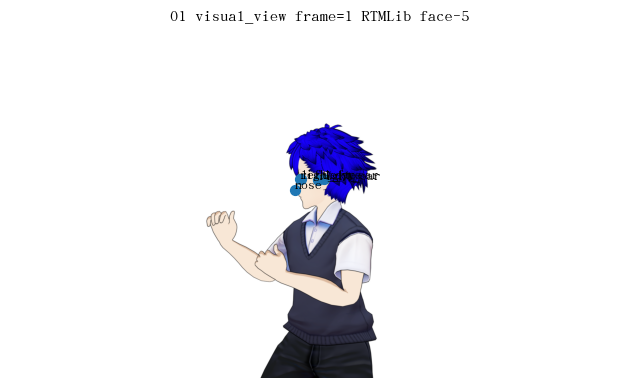

In [13]:
# 预览：RTMLib 补出的 face-5 点

def preview_face5(view_name=None, frame_id=1, device=None, backend=None):
    device = device or RTMLIB_DEVICE
    backend = backend or RTMLIB_BACKEND

    view_dir = [p for p in VIEW_DIRS if p.name == (view_name or VIEW_DIRS[0].name)][0]
    img, face5 = infer_face5_with_rtmlib(view_name=view_dir.name, frame_id=frame_id, device=device, backend=backend)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    xs = [v['x'] for v in face5.values()]
    ys = [v['y'] for v in face5.values()]
    plt.scatter(xs, ys, s=50)
    for name, p in face5.items():
        plt.text(p['x'], p['y'], name, fontsize=10)
    plt.title(f'{view_dir.name} frame={frame_id} RTMLib face-5')
    plt.axis('off')
    plt.show()

preview_face5(frame_id=1)

## 标准格式预览&特征点补全
补全特征点使用rtmlib，默认值：
- 模型为
- 使用coco17标准

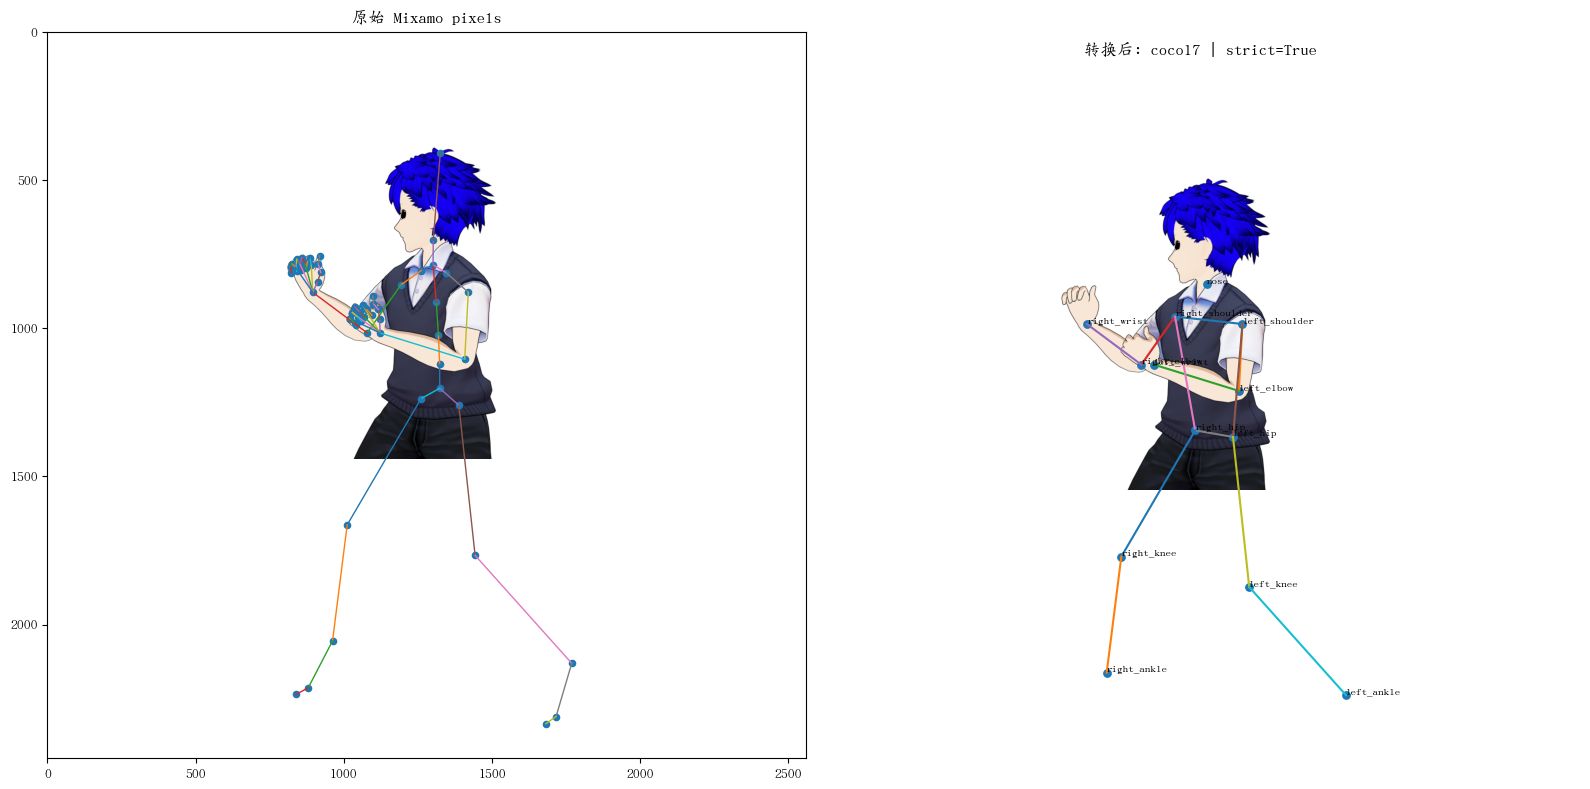

[coco17] 输出关键点:
 - nose
 - left_shoulder
 - right_shoulder
 - left_elbow
 - right_elbow
 - left_wrist
 - right_wrist
 - left_hip
 - right_hip
 - left_knee
 - right_knee
 - left_ankle
 - right_ankle


In [14]:

def draw_standard_points(ax, points, image=None, title='', show_labels=True, edges=None):
    if image is not None:
        ax.imshow(image)
    xs = [v['x'] for v in points.values()]
    ys = [v['y'] for v in points.values()]
    ax.scatter(xs, ys, s=28)
    if edges:
        for a, b in edges:
            if a in points and b in points:
                ax.plot([points[a]['x'], points[b]['x']], [points[a]['y'], points[b]['y']], linewidth=1.5)
    if show_labels:
        for name, p in points.items():
            ax.text(p['x'], p['y'], name, fontsize=8)
    ax.set_title(title)
    ax.axis('off')


# 用rtm补全特征点，包括COCO17的脸部5点，然后转换到标准格式预览
def preview_standard_conversion(view_name=None, frame_id=1, standard='coco17', use_rtmlib_face=True, strict=True, show_labels=True):
    view_dir = [p for p in VIEW_DIRS if p.name == (view_name or VIEW_DIRS[0].name)][0]
    img = read_image_rgb(frame_image_path(view_dir, frame_id))
    mixamo_pixels = load_points_for_frame(view_dir, 'pixels', frame_id)

    face5 = {}
    if use_rtmlib_face:
        try:
            _, face5 = infer_face5_with_rtmlib(view_name=view_dir.name, frame_id=frame_id)
        except Exception as e:
            print('RTMLib 补点失败，将只用已有 Mixamo 点回退:', e)

    std_points = convert_mixamo_to_standard(mixamo_pixels, standard=standard, extra_face_points=face5, strict=strict)

    if standard.lower() == 'coco17':
        edges = COCO17_EDGES
    elif standard.lower() == 'openpose18':
        edges = OPENPOSE18_EDGES
    else:
        edges = None

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    draw_points(axes[0], mixamo_pixels, title='原始 Mixamo pixels', image=img, show_labels=False, edges=MIXAMO_EDGES)
    draw_standard_points(axes[1], std_points, image=img, title=f'转换后: {standard} | strict={strict}', show_labels=show_labels, edges=edges)
    plt.tight_layout()
    plt.show()

    print(f'[{standard}] 输出关键点:')
    for k in std_points.keys():
        print(' -', k)

preview_standard_conversion(frame_id=1, standard='coco17', use_rtmlib_face=False, strict=True, show_labels=True)

In [15]:
# 交互式：标准格式转换与预览

view_dropdown2 = widgets.Dropdown(options=[p.name for p in VIEW_DIRS], value=VIEW_DIRS[0].name, description='View')
frame_slider2 = widgets.IntSlider(value=1, min=1, max=72, step=1, description='Frame')
standard_dropdown = widgets.Dropdown(options=['coco17', 'openpose18'], value='coco17', description='Standard')
rtmlib_check = widgets.Checkbox(value=True, description='用RTMLib补全脸部5点')
strict_check = widgets.Checkbox(value=True, description='strict标准')
labels_check2 = widgets.Checkbox(value=True, description='显示标签')

ui2 = widgets.VBox([
    widgets.HBox([view_dropdown2, frame_slider2]),
    widgets.HBox([standard_dropdown, rtmlib_check, strict_check, labels_check2]),
])

out2 = widgets.interactive_output(
    preview_standard_conversion,
    {
        'view_name': view_dropdown2,
        'frame_id': frame_slider2,
        'standard': standard_dropdown,
        'use_rtmlib_face': rtmlib_check,
        'strict': strict_check,
        'show_labels': labels_check2,
    }
)

display(ui2, out2)

Output()

# 导出某一帧的标准化结果 JSON
使用rtmlib推理补全点，并标准化特征点json到coco17/

In [16]:
def export_standard_json(view_name=None, frame_id=1, standard='coco17', use_rtmlib_face=True, strict=True, save_path=None):
    view_dir = [p for p in VIEW_DIRS if p.name == (view_name or VIEW_DIRS[0].name)][0]
    mixamo_pixels = load_points_for_frame(view_dir, 'pixels', frame_id)

    # rtm iference for face-5
    face5 = {}
    if use_rtmlib_face:
        try:
            _, face5 = infer_face5_with_rtmlib(view_name=view_dir.name, frame_id=frame_id)
        except Exception as e:
            print('RTMLib 补点失败，继续导出已有点:', e)

    # 转换到标准格式
    std_points = convert_mixamo_to_standard(mixamo_pixels, standard=standard, extra_face_points=face5, strict=strict)
    obj = {
        'view': view_dir.name,
        'frame_id': frame_id,
        'standard': standard,
        'strict': strict,
        'keypoints': std_points,
    }

    if save_path is None:
        save_path = ROOT / f'{view_prefix(view_dir)}_{frame_id:04d}_{standard}_strict{int(strict)}.json'
    save_path = Path(save_path)
    with open(save_path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    print('已导出:', save_path.resolve())
    return obj

# 示例：
export_standard_json(frame_id=1, standard='coco17', use_rtmlib_face=True, strict=True)

已导出: /home/tvem/anime/AniPose/68 model/01_0001_coco17_strict1.json


{'view': '01 visual_view',
 'frame_id': 1,
 'standard': 'coco17',
 'strict': True,
 'keypoints': OrderedDict([('nose',
               {'x': 1174.6085067325168, 'y': 662.7132822672527, 'z': 0.0}),
              ('left_eye',
               {'x': 1199.2885627746582, 'y': 616.8788938522339, 'z': 0.0}),
              ('right_eye',
               {'x': 1195.7628404829238, 'y': 616.8788938522339, 'z': 0.0}),
              ('left_ear',
               {'x': 1296.2459257973564, 'y': 618.6417549451191, 'z': 0.0}),
              ('right_ear',
               {'x': 1271.565869755215, 'y': 620.4046160380046, 'z': 0.0}),
              ('left_shoulder',
               {'x': 1420.1843804738492, 'y': 878.496356078842, 'z': 0.0}),
              ('right_shoulder',
               {'x': 1192.763831451044, 'y': 853.3267539889122, 'z': 0.0}),
              ('left_elbow',
               {'x': 1408.1649115605799, 'y': 1104.2914389150417, 'z': 0.0}),
              ('right_elbow',
               {'x': 1078.9275000

## 批量导出
遍历所有视角对应的72frames，导出标准化关键点 JSON
- 核心是调用`export_standard_json()`
- output_dir: 导出文件夹，如果为 None 则默认在 ROOT下创建`exported_{standard}_strict{0|1}` 文件夹
- 输出结构:

```text
output_dir/
      ├── 01_visual_view/
      │   ├── frame_0001_coco17_strict.json
      │   ├── frame_0002_coco17_strict.json
      │   └── ...
      ├── 02_visual_view/
      └── ...
```

In [17]:
from tqdm.auto import tqdm

In [18]:
def batch_export_all_views_frames(standard='coco17', use_rtmlib_face=True, strict=True, output_dir=None):
    """
    批量导出所有视角和帧的标准格式 JSON 文件。
    Args:
    - standard: 'coco17' 或 'openpose18'
    - use_rtmlib_face: 是否用 RTMLib 补全脸部5点
    - strict: 是否严格只保留标准定义的点（如果 False，则在结果里附带 neck / mid_hip）
    - output_dir: 导出文件夹，如果为 None 则默认在 ROOT下 创建exported_{standard}_strict{0|1} 文件夹
    Output:
    - output_dir: 导出文件夹路径
    - stats: {'success': int, 'failed': int} 导出成功和失败的统计

    """
    if output_dir is None:
        output_dir = ROOT / f'exported_{standard}_strict{int(strict)}'
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)
    
    print(f'mission started: {len(VIEW_DIRS)} views * 72frames')
    print(f'standard: {standard} | strict={strict} | RTMLib={use_rtmlib_face}')
    print(f'output dir={output_dir.resolve()}\n')
    
    stats = {'success': 0, 'failed': 0}
    
    for view_dir in tqdm(VIEW_DIRS, desc='views'):
        view_out_dir = output_dir / view_dir.name
        view_out_dir.mkdir(exist_ok=True)
        
        for frame_id in tqdm(range(1, 73), desc=f'{view_dir.name}', leave=False):
            try:
                save_path = view_out_dir / f'frame_{frame_id:04d}_{standard}_strict{int(strict)}.json'
                
                # infernce and export 
                export_standard_json(
                    view_name=view_dir.name,
                    frame_id=frame_id,
                    standard=standard,
                    use_rtmlib_face=use_rtmlib_face,
                    strict=strict,
                    save_path=save_path
                )
                stats['success'] += 1
            except Exception as e:
                stats['failed'] += 1
                tqdm.write(f'[{view_dir.name} frame={frame_id}] failed: {e}')
    
    print(f'\nall done. success {stats["success"]} | failed {stats["failed"]}')
    return output_dir, stats


In [19]:
output_dir, stats = batch_export_all_views_frames(
    standard='coco17',
    use_rtmlib_face=True,
    strict=True
) 

mission started: 5 views * 72frames
standard: coco17 | strict=True | RTMLib=True
output dir=/home/tvem/anime/AniPose/68 model/exported_coco17_strict1



views:   0%|          | 0/5 [00:00<?, ?it/s]

01 visual_view:   0%|          | 0/72 [00:00<?, ?it/s]

已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0001_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0002_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0003_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0004_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0005_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0006_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0007_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0008_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/01 visual_view/frame_0009_coco17_strict1.json
已导出: /home/tvem/ani

02 visual_view:   0%|          | 0/72 [00:00<?, ?it/s]

...

已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/03 visual_view/frame_0001_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/03 visual_view/frame_0002_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/03 visual_view/frame_0003_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/03 visual_view/frame_0004_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/03 visual_view/frame_0005_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/03 visual_view/frame_0006_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/03 visual_view/frame_0007_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/03 visual_view/frame_0008_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/03 visual_view/frame_0009_coco17_strict1.json
已导出: /home/tvem/ani

04 visual_view:   0%|          | 0/72 [00:00<?, ?it/s]

已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/04 visual_view/frame_0001_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/04 visual_view/frame_0002_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/04 visual_view/frame_0003_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/04 visual_view/frame_0004_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/04 visual_view/frame_0005_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/04 visual_view/frame_0006_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/04 visual_view/frame_0007_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/04 visual_view/frame_0008_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/04 visual_view/frame_0009_coco17_strict1.json
已导出: /home/tvem/ani

05 visual_view:   0%|          | 0/72 [00:00<?, ?it/s]

已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/05 visual_view/frame_0001_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/05 visual_view/frame_0002_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/05 visual_view/frame_0003_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/05 visual_view/frame_0004_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/05 visual_view/frame_0005_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/05 visual_view/frame_0006_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/05 visual_view/frame_0007_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/05 visual_view/frame_0008_coco17_strict1.json
已导出: /home/tvem/anime/AniPose/68 model/exported_coco17_strict1/05 visual_view/frame_0009_coco17_strict1.json
已导出: /home/tvem/ani